## Workspace setup

In [3]:
from datetime import datetime  
import uproot
from functools import partial
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

import importlib

# Notebooks run from VSCode use home directory as a base path
# while notebooks run from JupyterLab use the current directory as a base path
import sys, os

user = os.getenv("USER")
if user == "jovyan":
    sys.path.append("/home/jovyan/ELITPC/TPCReco/PythonAnalysis/python/")
else:
    sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")
    os.chdir('/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/ipynb/')

os.makedirs("fig_png", exist_ok=True)

## Training dataset preparation

In [ ]:
import io_functions as io
importlib.reload(io)

batchSize = 32
nBatches = 2000
dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_100k_fiducial', compression="GZIP")
dataset = dataset.batch(batchSize, drop_remainder=True)
dataset = dataset.map(lambda x: x['sim'])
dataset = dataset.map(lambda x,y: (tf.reshape(x, (-1,)+io.projections.shape), tf.reshape(y, (-1,9))))
dataset = dataset.prefetch(tf.data.AUTOTUNE)
#dataset = dataset.take(nBatches).cache()
tfds.benchmark(dataset.take(nBatches),batch_size=batchSize)


************ Summary ************



2026-03-31 14:06:37.105554: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 14:06:37.107887: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-31 14:06:37.116600: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

  0%|          | 0/500 [00:00<?, ?it/s]

Examples/sec (First included) 296.32 ex/sec (total: 16032 ex, 54.10 sec)
Examples/sec (First only) 200.59 ex/sec (total: 32 ex, 0.16 sec)
Examples/sec (First excluded) 296.61 ex/sec (total: 16000 ex, 53.94 sec)


2026-03-31 14:07:32.941904: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,duration,num_examples,avg
first+lasts,54.103302,16032,296.322024
first,0.159527,32,200.593101
lasts,53.943775,16000,296.605121


## Model definition

In [5]:
def getModel():

  model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(256,512,3), name="input_image", dtype=tf.float32),
  tf.keras.layers.Resizing(height=256, width=256), 
  tf.keras.layers.Conv2D(16, 4, padding='same', activation='relu', 
                          data_format="channels_last"),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 2, padding='same', activation='relu', 
                          data_format="channels_last"),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(64, 2, padding='same', activation='relu', 
                          data_format="channels_last"),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(16, activation='relu',
                          kernel_initializer=tf.keras.initializers.HeNormal(),
                          bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
  tf.keras.layers.Dense(16, activation='relu',
                          kernel_initializer=tf.keras.initializers.HeNormal(),
                          bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
  tf.keras.layers.Dense(16, activation='relu',
                          kernel_initializer=tf.keras.initializers.HeNormal(),
                          bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
  tf.keras.layers.Dense(16, activation='relu',
                          kernel_initializer=tf.keras.initializers.HeNormal(),
                          bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
  tf.keras.layers.Dense(16, activation='relu',
                          kernel_initializer=tf.keras.initializers.HeNormal(),
                          bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
  tf.keras.layers.Dense(9, activation="linear")
  ])

  initial_learning_rate = 0.01
  lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate,
                  decay_steps=836,
                  decay_rate=0.98,
                  staircase=False)

  optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule) 
  model.compile(optimizer = optimizer, 
                loss = 'mse', 
                metrics=['mse', 'mape']) 

  model.summary()
  return model
#########################################################
#########################################################  
def getModel_1():

    model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(256,512,3), name="input_image", dtype=tf.float32),
      tf.keras.layers.Conv2D(filters = 16*3, kernel_size = (16,32), groups=3,
                             padding='same', activation='relu', 
                             data_format="channels_last"),
      tf.keras.layers.MaxPooling2D(pool_size=(16, 32)),
      tf.keras.layers.Conv2D(filters=16*3, kernel_size=(8,16), groups=3,
                              padding='same', activation='relu', 
                              data_format="channels_last"),
      tf.keras.layers.MaxPooling2D(),
      tf.keras.layers.Conv2D(filters=8*3, kernel_size=2, groups=3, 
                             padding='same', activation='relu', 
                              data_format="channels_last"),
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(16, activation='relu',
                              kernel_initializer=tf.keras.initializers.HeNormal(),
                              bias_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1)),
      tf.keras.layers.Dense(9, activation="linear")
      ])

    initial_learning_rate = 0.01
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate,
                      decay_steps=1990,
                      decay_rate=0.98,
                      staircase=False)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule) 
    model.compile(optimizer = optimizer, 
                    loss = 'mse', 
                    metrics=['mse', 'mape']) 
    
    model.summary()
    return model
##########################################################
##########################################################

In [ ]:
model = getModel_1()
#model = getModelWithTL()

#model_path = "./training/0100_2025_Oct_13_18_48_39.keras"
#model = tf.keras.models.load_model(model_path)
#model.evaluate(dataset.take(10))
#model.summary()

#item = next(iter(dataset.take(1)))
#model(item)[0]

## Model training

In [ ]:
%%time

import plotting_functions as plf
importlib.reload(plf)

log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")
#tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, profile_batch=(10, 20))
early_stop_callback = tf.keras.callbacks.EarlyStopping(patience=2, verbose=1)
callbacks =  [early_stop_callback] 

epochs=50
model = getModel_1()
#model_path = "./training/0100_2026_Mar_27_17_45_38.keras" #  val_mse: 1.5725
#model = tf.keras.models.load_model(model_path)
model.trainable = True

initial_learning_rate = 0.001
decay_steps = 5*nBatches
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate,
                  decay_steps=decay_steps,
                  decay_rate=0.98,
                  staircase=False)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule) 
model.compile(optimizer = optimizer, 
                loss = 'mse', 
                metrics=['mse']) 

history = model.fit(dataset.skip(10), 
                        epochs=epochs,
                        verbose = 1,
                        validation_data = dataset.take(10),
                        callbacks=callbacks
                        )
plf.plotTrainHistory(history)

current_time = datetime.now().strftime("%Y_%b_%d_%H_%M_%S")
print("Training start. Current Time =", current_time)

job_dir = f"training/{epochs:04d}_"+current_time+".keras"
model.save(job_dir)

job_dir = f"training/{epochs:04d}_"+current_time+"/"
model.export(job_dir)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 512, 48)   │        24,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        98,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 24)       │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        24,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,097 (586.32 KB)

 Trainable params: 150,097 (586.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


I0000 00:00:1774958886.708101  180314 service.cc:145] XLA service 0x72c9fc001ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774958886.708126  180314 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1774958886.708128  180314 service.cc:153]   StreamExecutor device (1): NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5
2026-03-31 14:08:06.756800: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-31 14:08:06.945103: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8906
2026-03-31 14:08:12.600608: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng28{k2=1,k3=0} for conv (f32[32,48,256,512]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,271,543]{3,2,1,0}, f32[48,1,16,32]{3,2,1,0}), window={size=16x32}, d

  1/490 ━━━━━━━━━━━━━━━━━━━━ 6:31:45 48s/step - loss: 1844.0837 - mse: 1844.0837

I0000 00:00:1774958933.161632  180314 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


265/490 ━━━━━━━━━━━━━━━━━━━━ 51s 229ms/step - loss: 1165.7803 - mse: 1165.7803

## Model performance on training data.

Fill Pandas DataFrame with true and response values.

In [16]:
%%time
import utility_functions as utils
importlib.reload(utils)
import pandas as pd
#model_path = "./training/0050_2025_Oct_14_15_14_48.keras"
#model_path = "./training/0020_2025_Nov_27_13_05_07.keras"
#model_path = "./training/0100_2026_Mar_26_19_07_35.keras" # val_mse: 5.4584
#model_path = "./training/0010_2026_Mar_27_11_28_29.keras" # val_mse: 4.6312
#model_path = "./training/0010_2026_Mar_27_15_08_49.keras" #  val_mse: 3.0631
#model_path = "./training/0100_2026_Mar_27_17_45_38.keras" #  val_mse: 1.5725
#model = tf.keras.models.load_model(model_path)

nBatches = 1_000
data = np.zeros_like(utils.getSimRecoColumns(utils.columnsXYZ).reshape(1,-1), dtype=float) 

for aBatch in dataset.take(nBatches):
    features = aBatch[0]
    labels = aBatch[1].numpy()
    modelAnswer = model(features).numpy()
    data = np.append(data, np.column_stack((labels,modelAnswer)), axis=0)

df_XYZ = pd.DataFrame(data=data[1:], columns = utils.getSimRecoColumns(utils.columnsXYZ))
df_XYZ.describe()  

CPU times: user 3min 5s, sys: 51.1 s, total: 3min 56s
Wall time: 3min 13s


2026-03-30 13:26:15.208648: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,xVtx_sim,xAlpha_sim,xCarbon_sim,yVtx_sim,yAlpha_sim,yCarbon_sim,zVtx_sim,zAlpha_sim,zCarbon_sim,xVtx_reco,xAlpha_reco,xCarbon_reco,yVtx_reco,yAlpha_reco,yCarbon_reco,zVtx_reco,zAlpha_reco,zCarbon_reco
count,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000,27072.000000
mean,0.342247,0.032252,-0.357470,-0.011363,-0.600337,0.085215,-35.544675,-35.443505,-35.570478,1.275944,-3.085473,1.132674,0.560923,0.011711,0.366596,-34.539295,-35.138051,-34.515358
std,59.271935,74.068907,58.863225,2.008201,38.719292,6.053907,19.620526,24.062743,24.130258,59.946919,73.090574,59.807248,0.434828,38.310919,5.331114,19.556569,23.933380,24.093847
min,-99.998398,-164.977859,-111.635628,-7.539874,-98.750000,-23.481716,-52.944485,-57.980431,-52.946159,-106.447495,-181.374466,-111.335960,-1.565369,-105.625053,-15.190318,-55.606426,-61.554802,-57.872654
25%,-51.848768,-53.719586,-52.508917,-1.362604,-27.783768,-4.579179,-48.981655,-52.930757,-52.946159,-51.035096,-55.396025,-51.614796,0.263316,-26.757090,-3.499763,-47.881250,-52.498511,-51.745348
50%,0.548669,0.779535,-0.097996,-0.013408,-0.867392,0.149948,-44.945442,-51.596191,-52.396914,1.758223,-2.705609,1.845440,0.542398,-0.375509,0.432971,-44.140379,-49.595169,-49.782551
75%,52.699168,53.622293,51.915957,1.321854,26.564645,4.723092,-26.301210,-21.146554,-21.589030,54.090675,49.477230,54.031373,0.851565,26.917562,4.214873,-24.902625,-21.061680,-20.467367
max,99.984314,164.977814,110.067688,7.593938,98.750000,27.350050,44.794102,65.891998,56.487419,107.962311,174.251297,119.844116,2.587020,108.507660,15.276507,44.896053,56.639130,57.649654


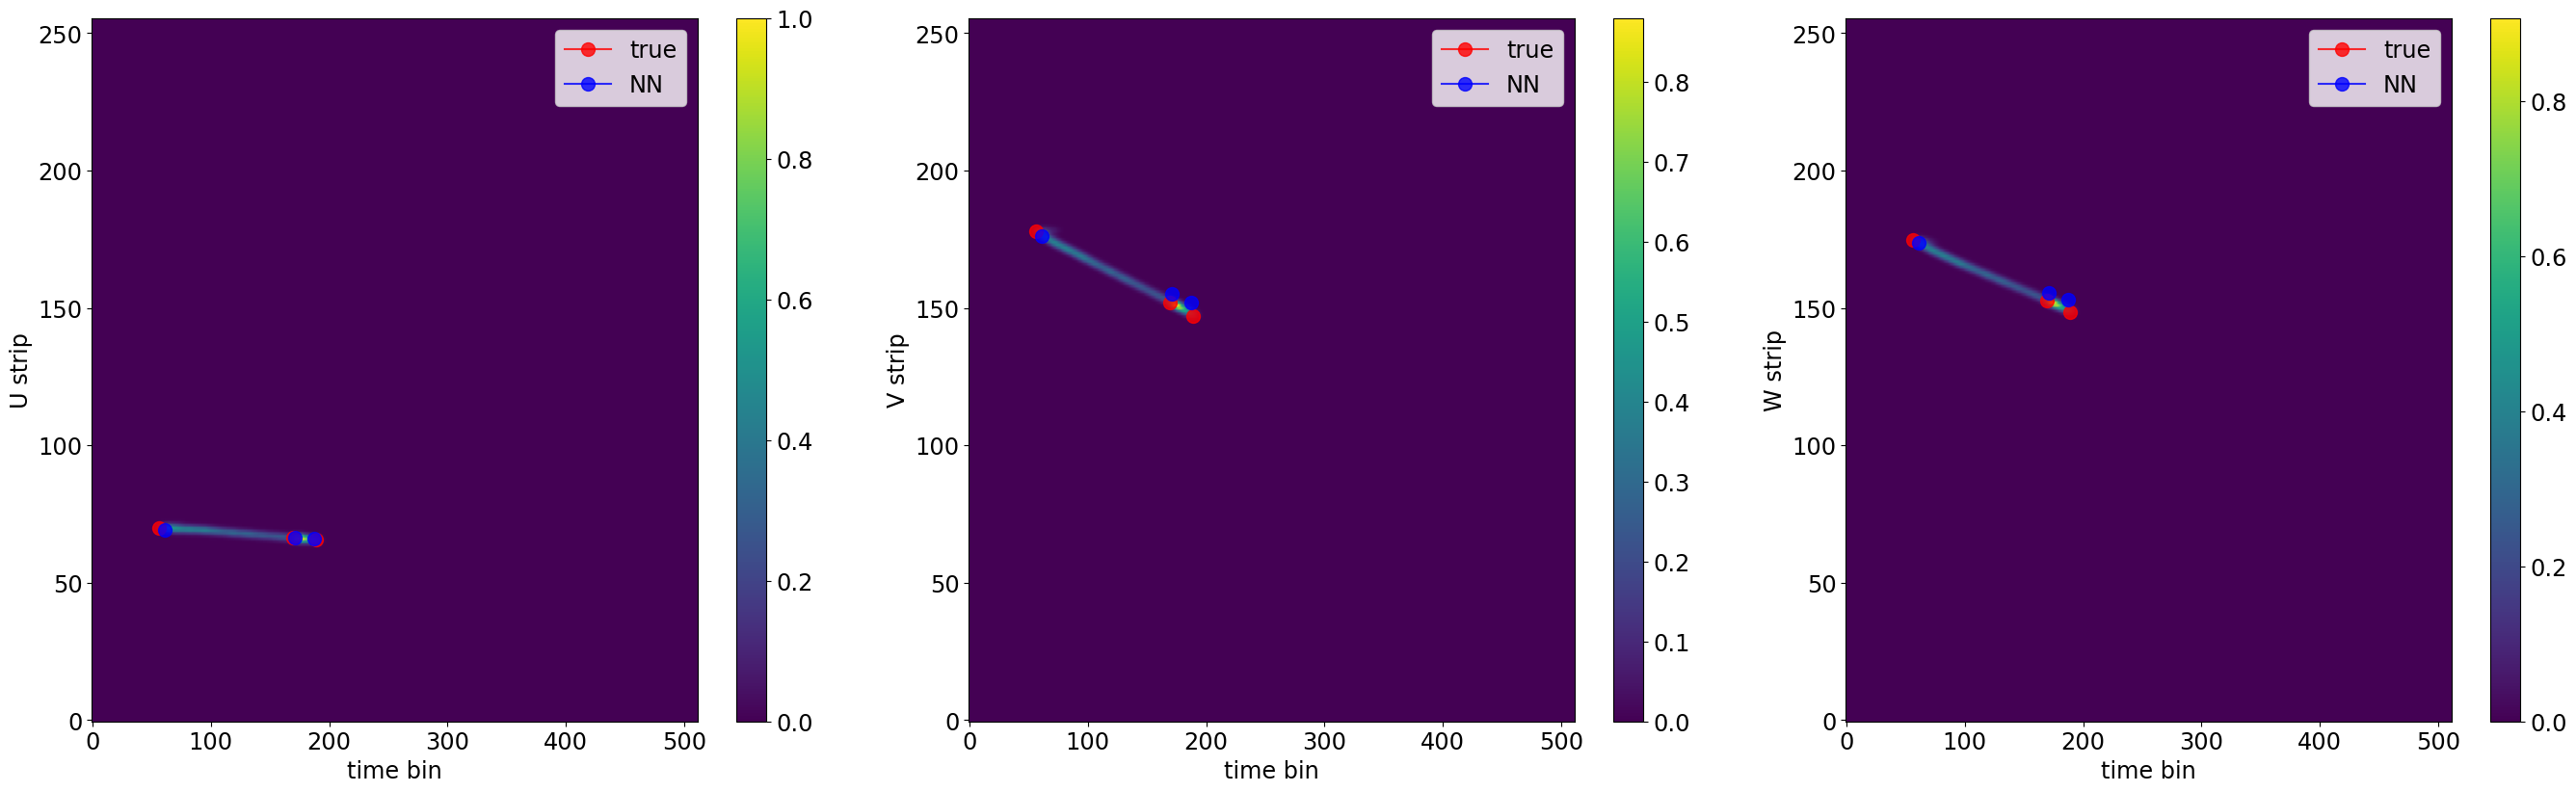

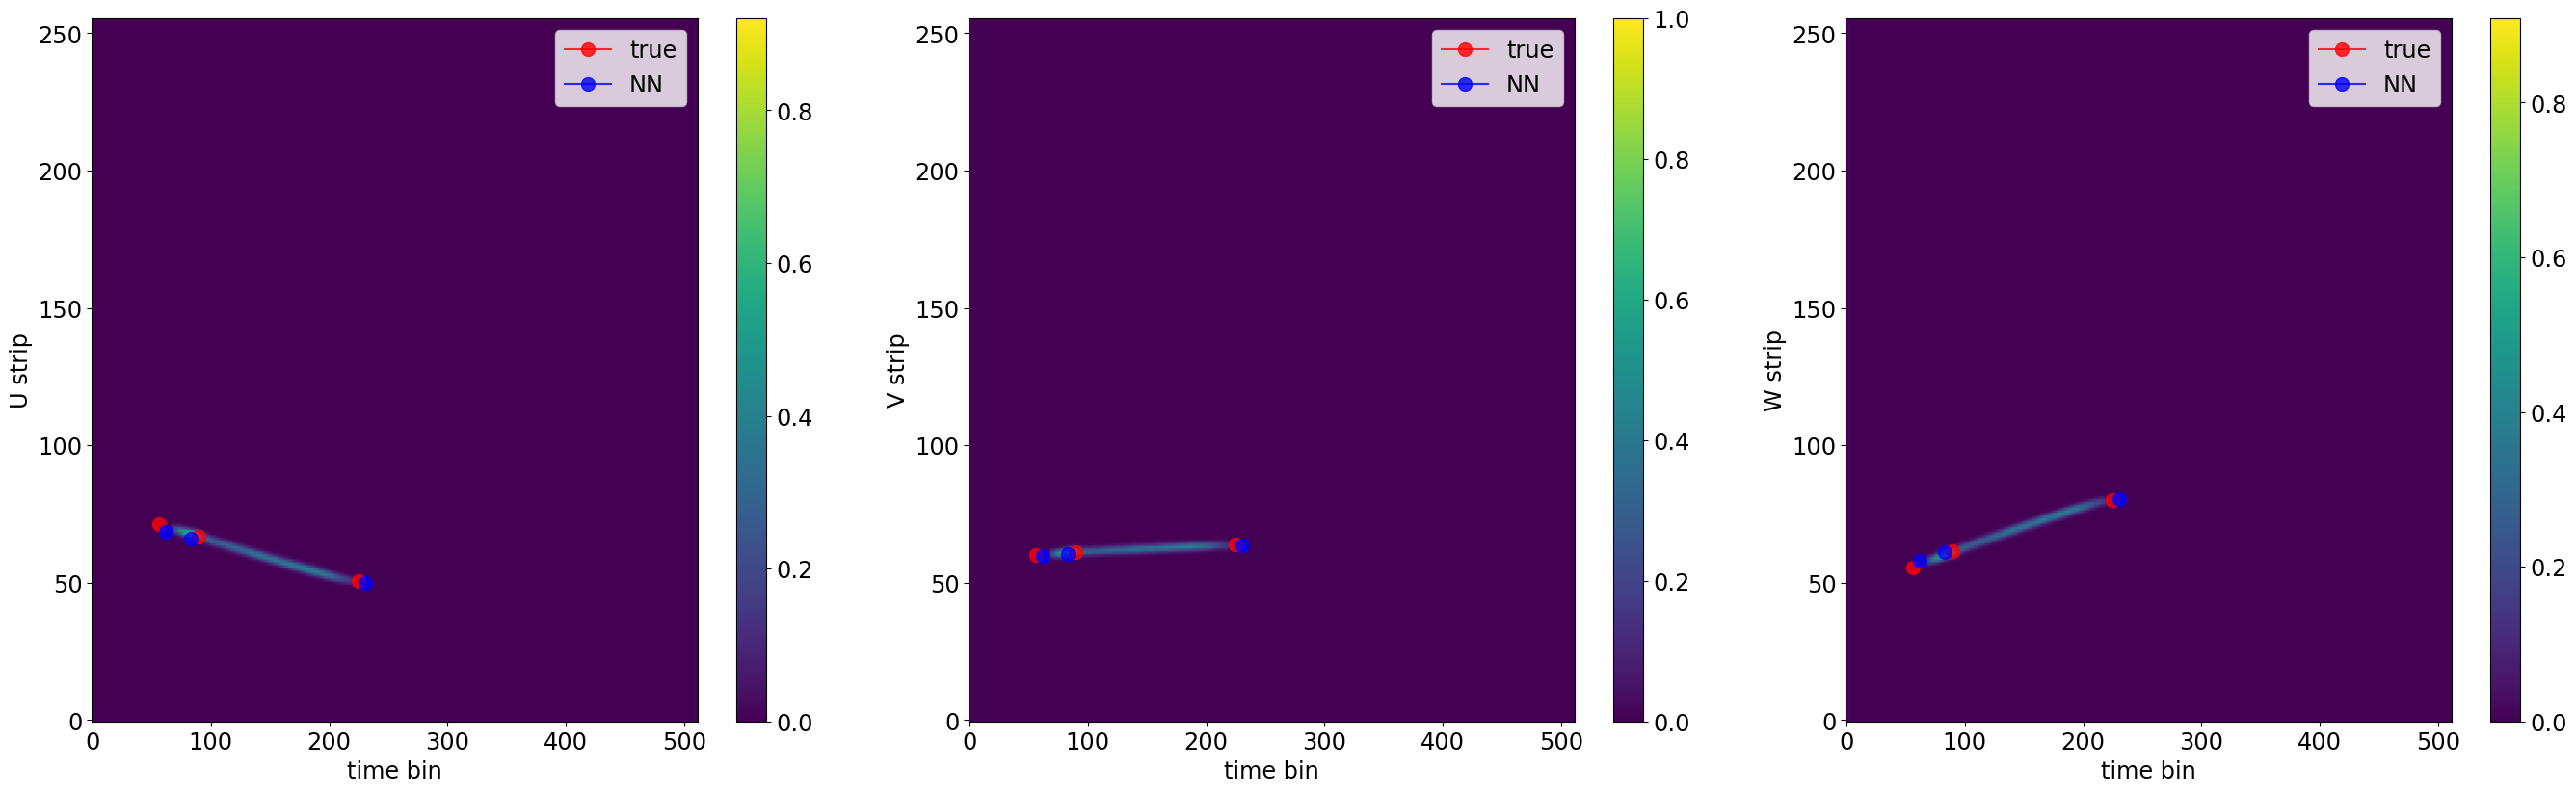

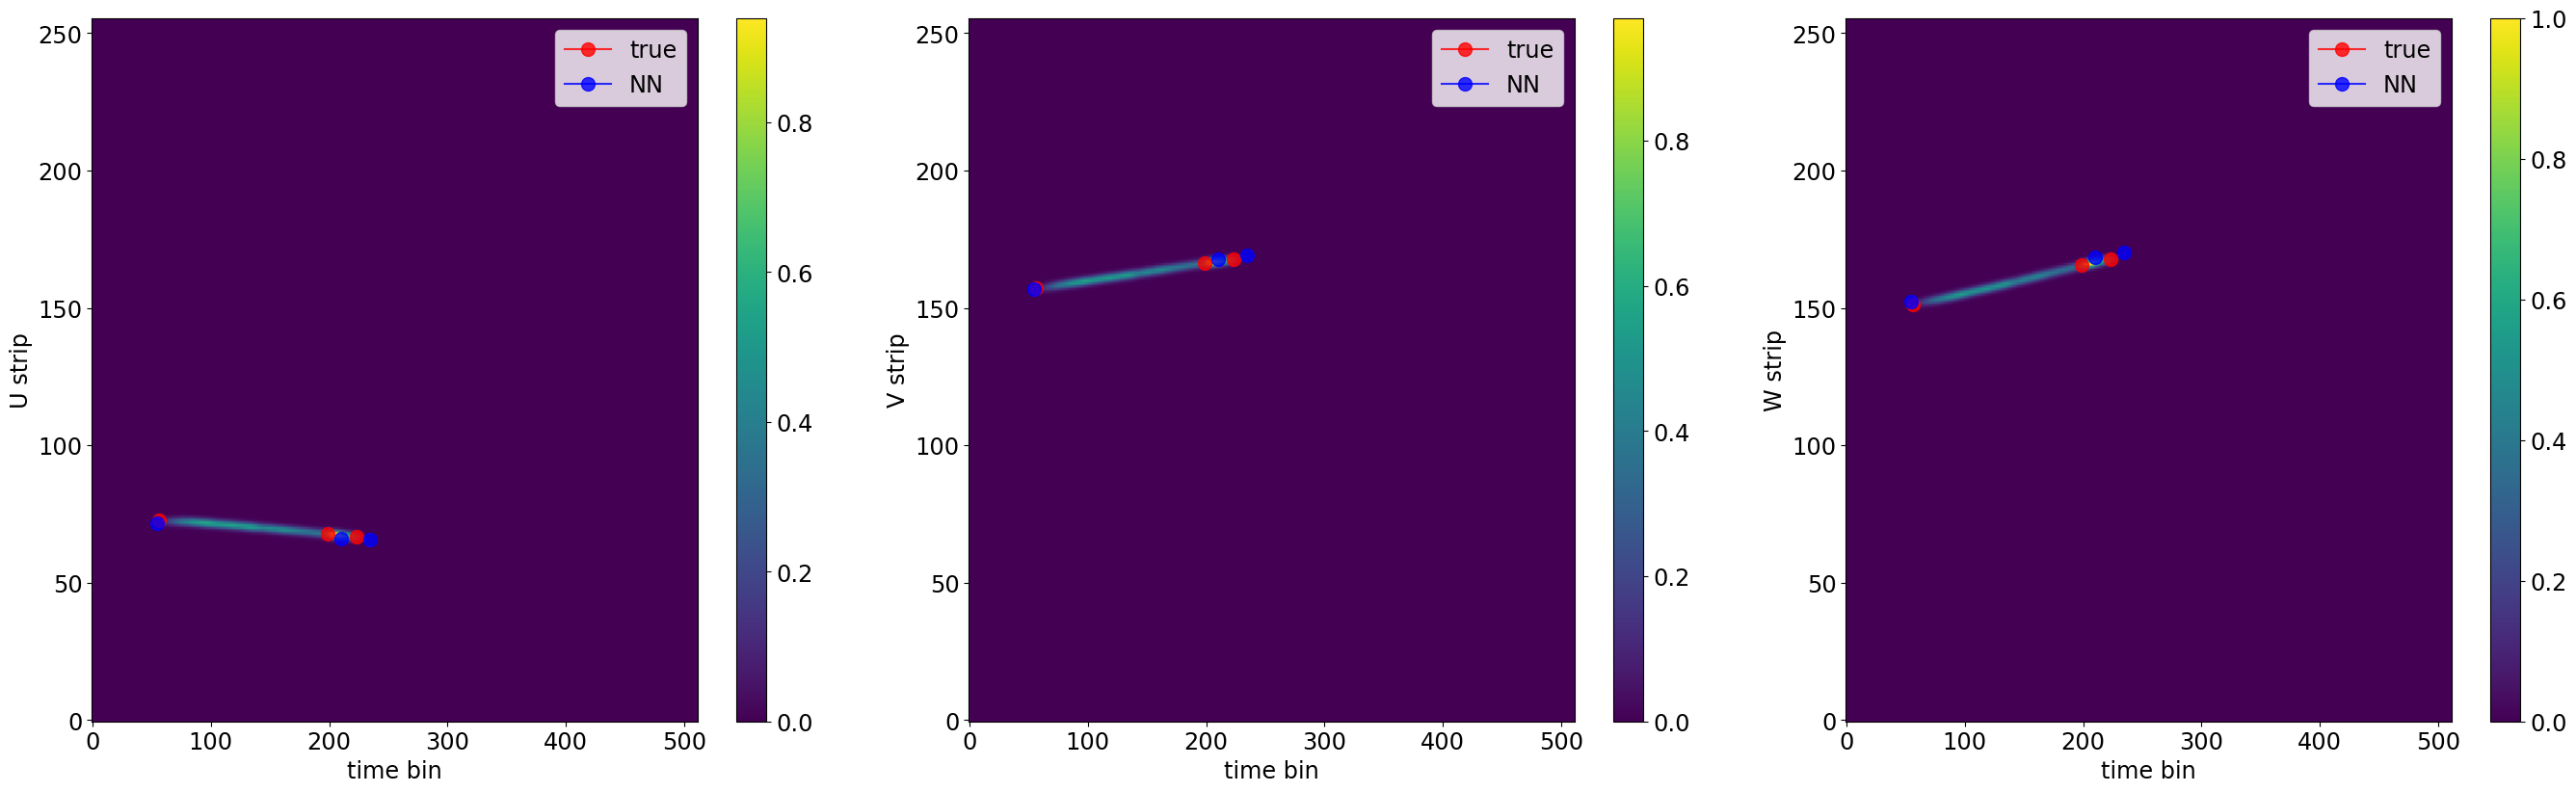

In [17]:
import plotting_functions as plf
importlib.reload(plf)

import utility_functions as utils
importlib.reload(utils)

for aBatch in dataset.skip(100).take(3):
    plf.plotEvent(aBatch, model=model)

### Resolution plots

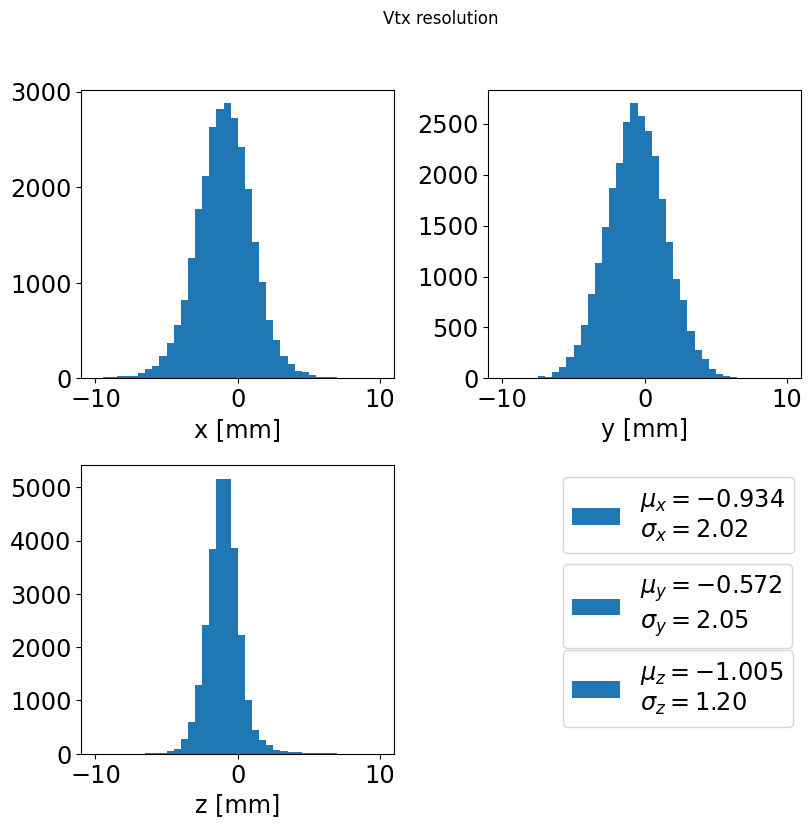

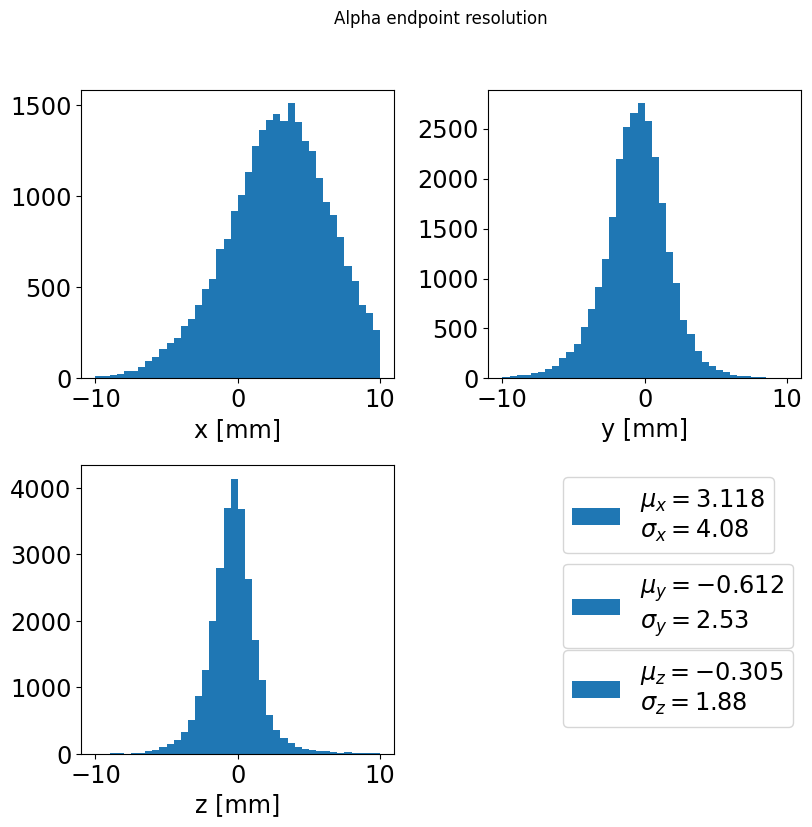

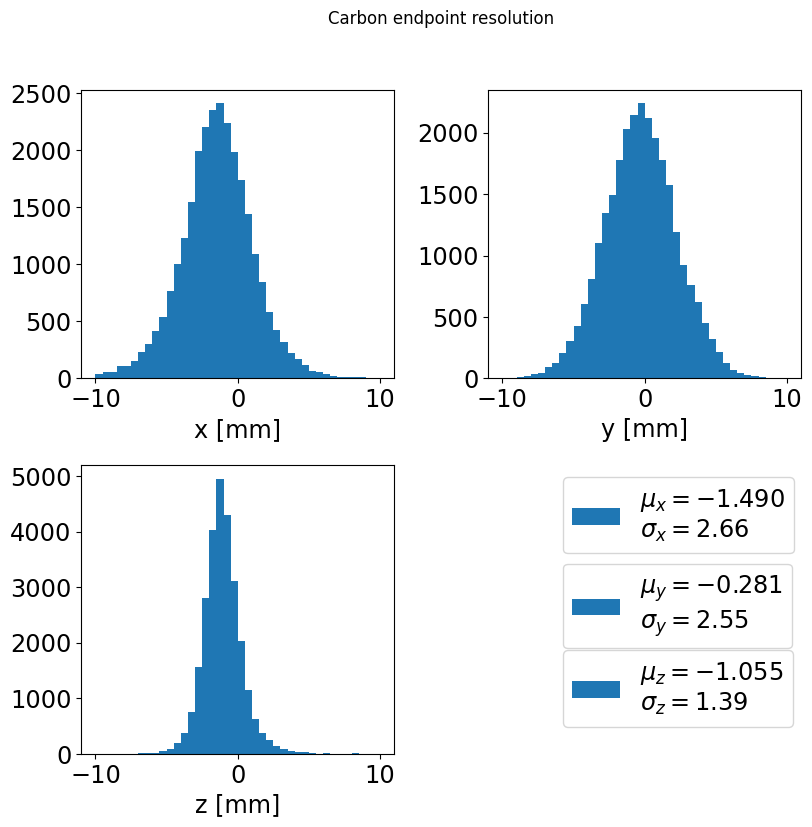

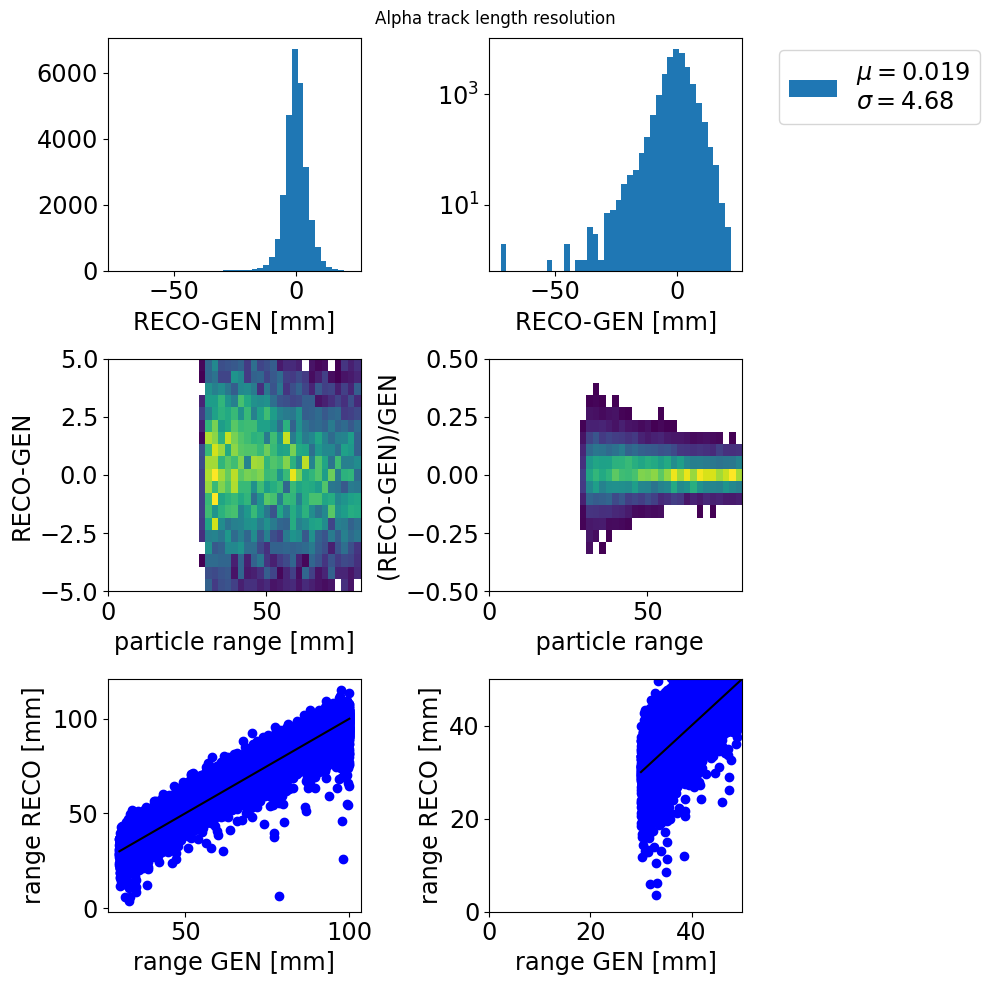

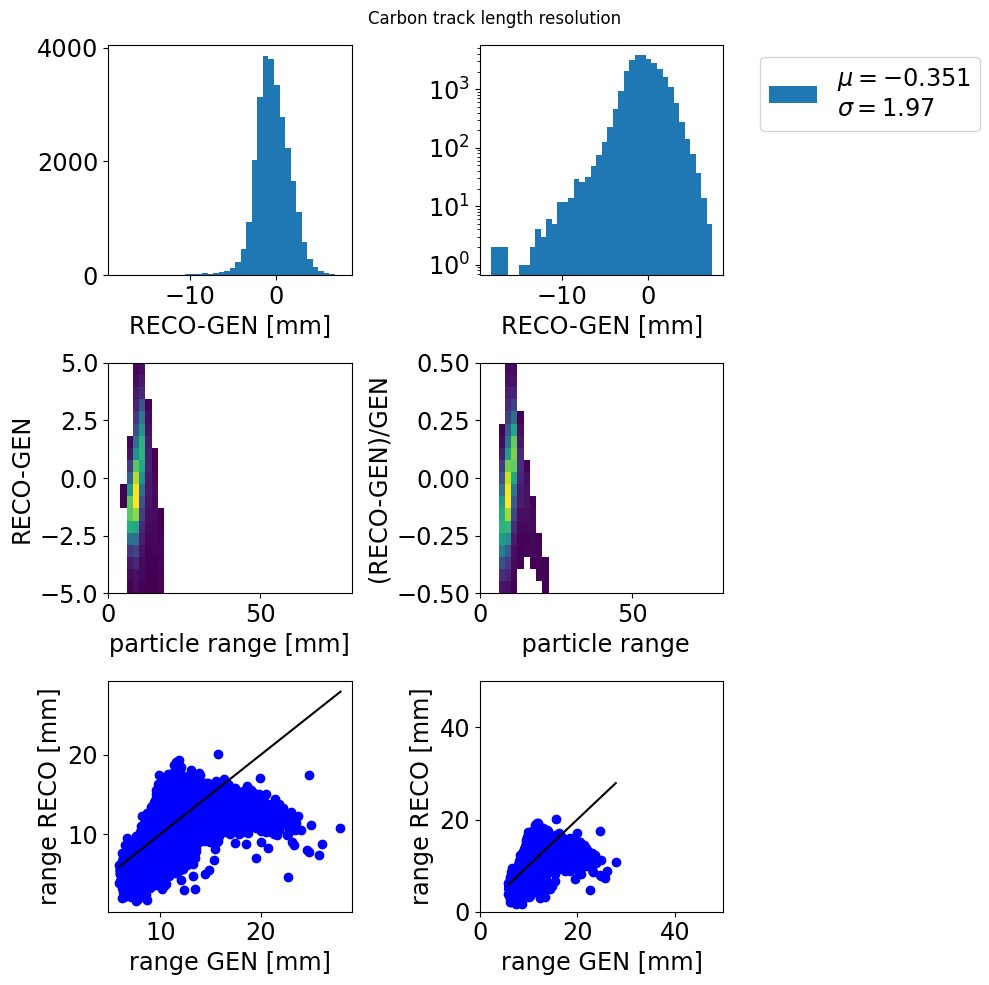

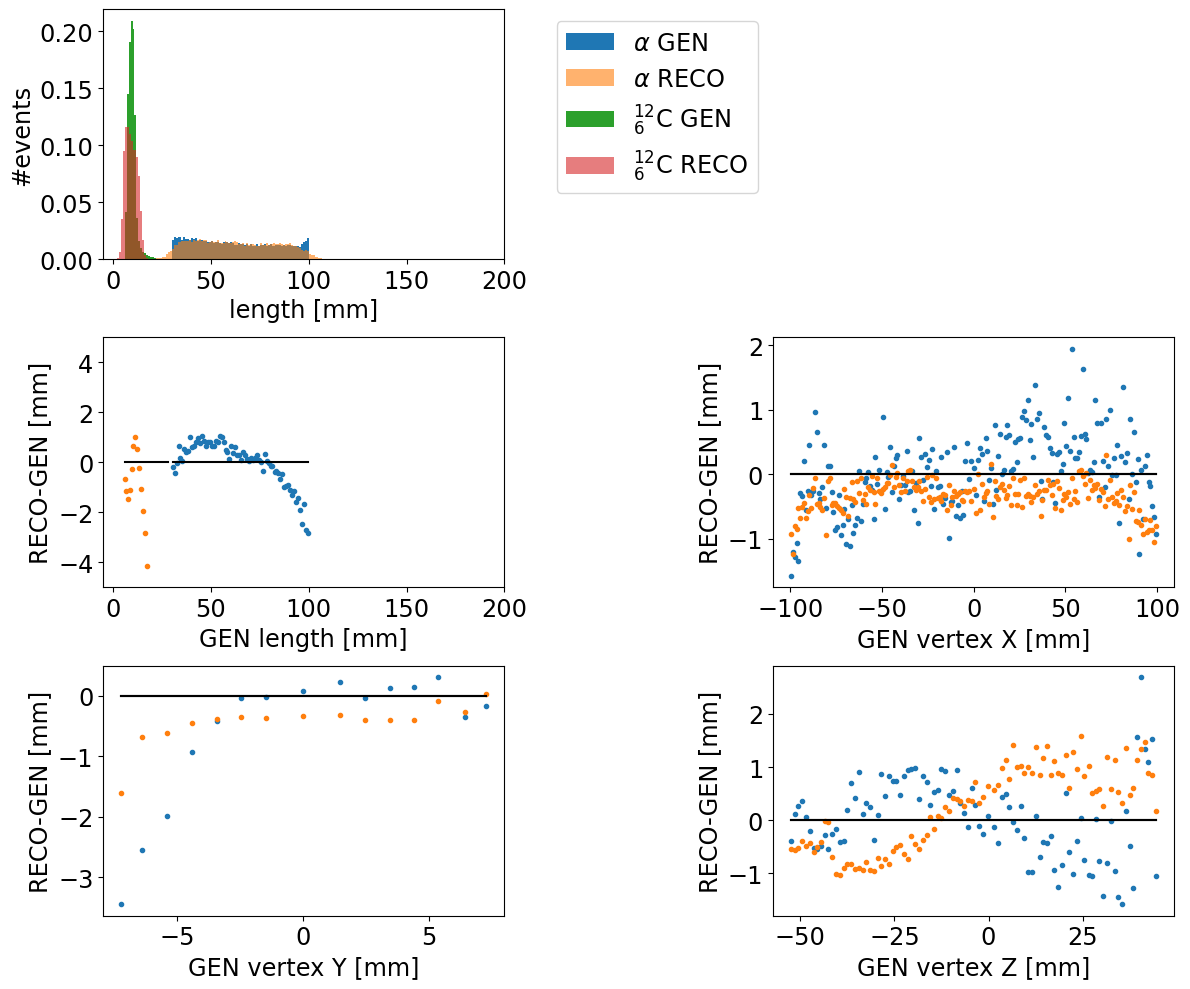

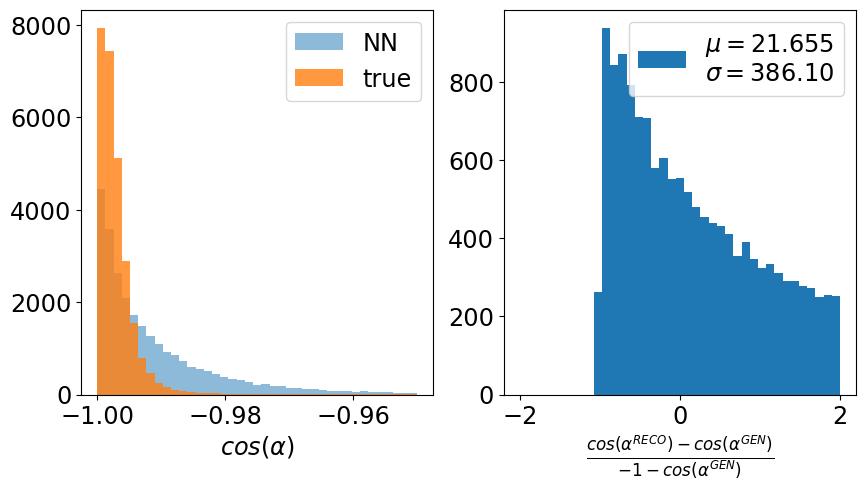

In [ ]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
plf.plotEndPointRes(df=df_XYZ, edge="Vtx",coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df_XYZ, edge="Alpha",coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df_XYZ, edge="Carbon",coordinates=["x", "y", "z"])

plf.plotLengthPull(df_XYZ, partName="Alpha")
plf.plotLengthPull(df_XYZ, partName="Carbon")
plf.plotLengthPullEvolution(df_XYZ)
plf.plotOpeningAngleCos(df_XYZ)

numeratorSelection = (df_XYZ["pullAlpha"]/df_XYZ["dAlpha_sim"] < 0.05)
denominatorSelection = (np.abs(df_XYZ["xAlpha_sim"]) < 140) & (np.abs(df_XYZ["yAlpha_sim"]) < 90) & (np.abs(df_XYZ["zAlpha_sim"]) < 60)

plf.plotEffMaps(df_XYZ, numeratorSelection, denominatorSelection)

## Various tests

/tmp/ipykernel_3965/617587210.py:51: RuntimeWarning: invalid value encountered in divide
  eff = numerator / denominator


(0.0, 1.05)

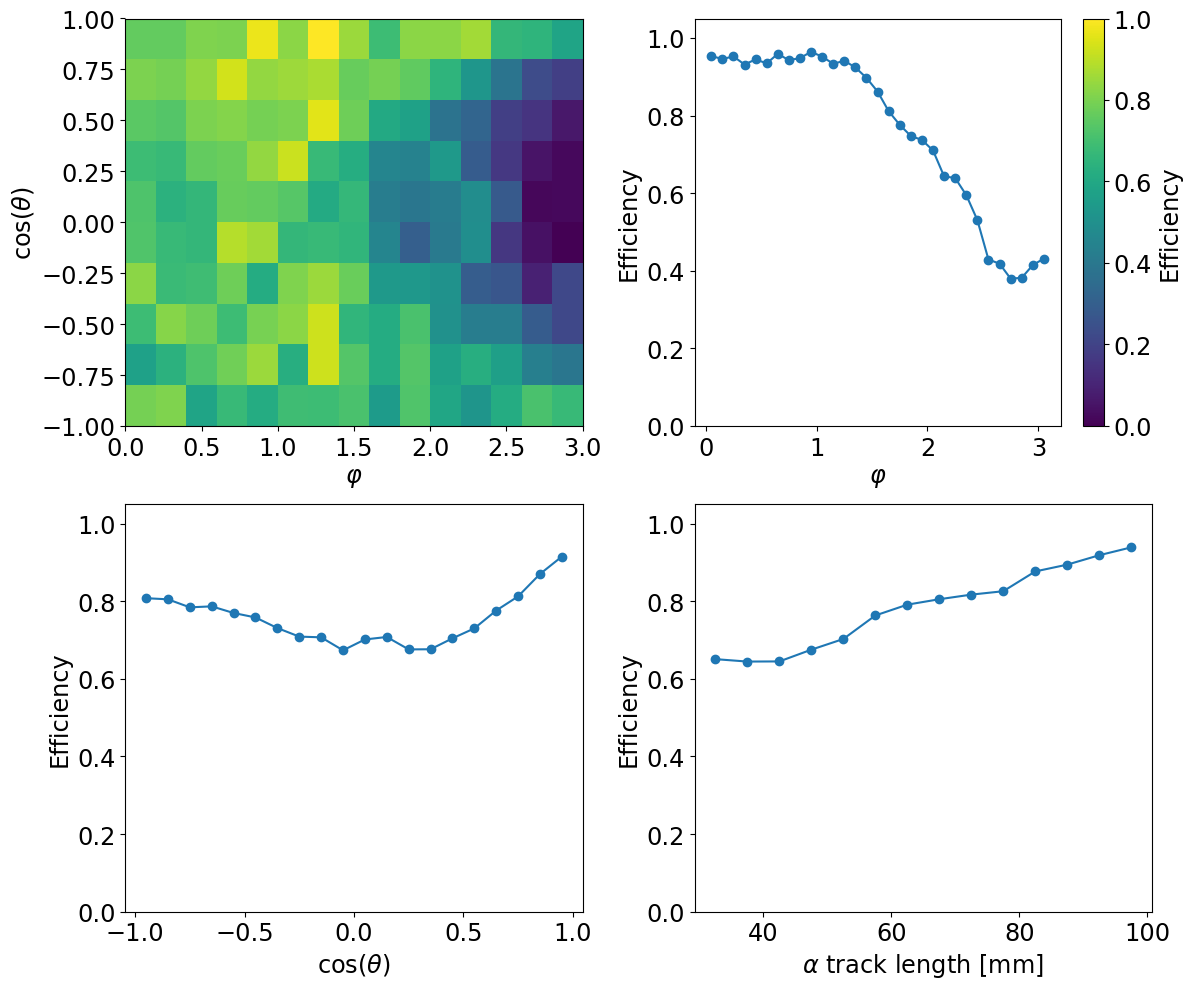

In [19]:
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

df_XYZ["cosTheta_sim"] = (df_XYZ["zAlpha_sim"] - df_XYZ["zVtx_sim"])/df_XYZ["dAlpha_sim"]
df_XYZ["cosPhi_sim"] = (df_XYZ["xAlpha_sim"] - df_XYZ["xVtx_sim"])/np.sqrt((df_XYZ["xAlpha_sim"] - df_XYZ["xVtx_sim"])**2 + (df_XYZ["yAlpha_sim"] - df_XYZ["yVtx_sim"])**2 )
df_XYZ["phi_sim"] = np.arccos(df_XYZ["cosPhi_sim"])

goodFiducial = (np.abs(df_XYZ["xVtx_sim"] + df_XYZ["dAlpha_sim"] * np.sqrt(1 - df_XYZ["cosTheta_sim"]**2) * np.cos(df_XYZ["phi_sim"])) < 140) & \
                (np.abs(df_XYZ["yVtx_sim"] + df_XYZ["dAlpha_sim"] * np.sqrt(1 - df_XYZ["cosTheta_sim"]**2) * np.sin(df_XYZ["phi_sim"])) < 90) & \
                (np.abs(df_XYZ["zVtx_sim"] + df_XYZ["dAlpha_sim"] * df_XYZ["cosTheta_sim"]) < 60)

goodReco = (df_XYZ["pullAlpha"]/df_XYZ["dAlpha_sim"] < 0.05)
df_good_gen = df_XYZ[goodFiducial]
df_good_reco = df_XYZ[goodReco*goodFiducial]

fig, axes = plt.subplots(2,2, figsize=(12,10), layout='tight')

#2d efficiency
denominator, _,_,_ = axes[0,0].hist2d(df_good_gen["phi_sim"], df_good_gen["cosTheta_sim"], bins=(np.arange(0, np.pi, 0.2), np.arange(-1,1.1,0.2)))
numerator, _,_,_   = axes[0,0].hist2d(df_good_reco["phi_sim"], df_good_reco["cosTheta_sim"], bins=(np.arange(0, np.pi, 0.2), np.arange(-1,1.1,0.2)))
eff = numerator / denominator
axes[0,0].imshow(eff.T, origin='lower', aspect='auto', extent=[0, np.pi, -1, 1])
axes[0,0].set_xlabel(r"$\varphi$")
axes[0,0].set_ylabel(r"$\cos(\theta)$")
fig.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=axes[0,1], label='Efficiency')

# 1d versus phi
denominator, _,_ = axes[0,1].hist(df_good_gen["phi_sim"], bins=np.arange(0, np.pi, 0.1))
numerator, _,_   = axes[0,1].hist(df_good_reco["phi_sim"], bins=np.arange(0, np.pi, 0.1))
eff = numerator / denominator
axes[0,1].clear()
axes[0,1].plot((np.arange(0, np.pi, 0.1)[:-1] + np.arange(0, np.pi, 0.1)[1:])/2, eff, marker='o')
axes[0,1].set_xlabel(r"$\varphi$")
axes[0,1].set_ylabel("Efficiency")
axes[0,1].set_ylim(0, 1.05)

# 1d versus cosTheta
denominator, _,_ = axes[1,0].hist(df_good_gen["cosTheta_sim"], bins=np.arange(-1,1.1,0.1))
numerator, _,_   = axes[1,0].hist(df_good_reco["cosTheta_sim"], bins=np.arange(-1,1.1,0.1))
eff = numerator / denominator
axes[1,0].clear()
axes[1,0].plot((np.arange(-1,1.1,0.1)[:-1] + np.arange(-1,1.1,0.1)[1:])/2, eff, marker='o')
axes[1,0].set_xlabel(r"$\cos(\theta)$")
axes[1,0].set_ylabel("Efficiency")
axes[1,0].set_ylim(0, 1.05)

# 1d versus track length
denominator, _,_ = axes[1,1].hist(df_good_gen["dAlpha_sim"], bins=np.arange(0, 200, 5))
numerator, _,_   = axes[1,1].hist(df_good_reco["dAlpha_sim"], bins=np.arange(0, 200, 5))
eff = numerator / denominator
axes[1,1].clear()
axes[1,1].plot((np.arange(0, 200, 5)[:-1] + np.arange(0, 200, 5)[1:])/2, eff, marker='o')
axes[1,1].set_xlabel(r"$\alpha$ track length [mm]")
axes[1,1].set_ylabel("Efficiency")
axes[1,1].set_ylim(0, 1.05)